# P5 — Granularity EDA: Half-hourly vs Daily

Establishes how much detail is gained or lost between half-hourly and daily resolution (zero-inflation, distribution shape, week-level texture, seasonal signal), train-split only. Fuel types: the 5 stratified (WIND, CCGT, NPSHYD, NUCLEAR, OCGT) plus COAL and BIOMASS for baseload/intermittent contrast.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path

pd.set_option("display.max_columns", 50)
pd.set_option("display.width", 160)

INTERIM_DIR = Path("../data/interim")
REF_DIR = Path("../data/reference")

# Fixed colour per fuel type throughout this notebook - never reassigned, never
# cycled, so the same fuel type always reads as the same colour across every plot.
FUEL_COLOURS = {
    "WIND": "#2a78d6",
    "CCGT": "#eb6834",
    "NPSHYD": "#1baf7a",
    "NUCLEAR": "#eda100",
    "OCGT": "#e87ba4",
    "COAL": "#008300",
    "BIOMASS": "#4a3aa7",
}
FUEL_TYPES = list(FUEL_COLOURS.keys())  # stratified five + two sub-threshold for contrast

plt.rcParams.update({
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 10,
})

## Load train-only data, cross-checked against `site_split_assignment.csv`

In [2]:
# Authoritative split source, checked against the parquet's own split column
split_assignment = pd.read_csv(REF_DIR / "site_split_assignment.csv")
train_keys = set(
    zip(split_assignment.loc[split_assignment["split"] == "train", "dictionary_id"],
        split_assignment.loc[split_assignment["split"] == "train", "fuel_type"])
)

raw = pd.read_parquet(INTERIM_DIR / "site_generation_consolidated.parquet")
assert set(raw["split"].unique()) <= {"train", "val", "test"}

df = raw.loc[raw["split"] == "train"].copy()
del raw  # don't keep the full (incl. val/test) frame around any longer than needed

# Sanity-check the parquet's split column against the CSV, since the brief treats them as equivalent
parquet_train_keys = set(zip(df["dictionary_id"], df["fuel_type"]))
assert parquet_train_keys == train_keys, "parquet split column disagrees with site_split_assignment.csv"

df = df[df["fuel_type"].isin(FUEL_TYPES)].reset_index(drop=True)

# Half-hourly timestamp from settlementDate + settlementPeriod (period 1 = 00:00-00:30)
df["settlementDate"] = pd.to_datetime(df["settlementDate"])
df["timestamp"] = df["settlementDate"] + pd.to_timedelta((df["settlementPeriod"] - 1) * 30, unit="min")

print(f"Train-only rows: {len(df):,}")
print(f"Train sites (site_fuel_id) by fuel type covered here:")
print(df.groupby("fuel_type")["site_fuel_id"].nunique().reindex(FUEL_TYPES))

Train-only rows: 16,664,266
Train sites (site_fuel_id) by fuel type covered here:


fuel_type
WIND       80
CCGT       26
NPSHYD      9
NUCLEAR     4
OCGT        7
COAL        4
BIOMASS     3
Name: site_fuel_id, dtype: int64


## Step 1 — Half-hourly zero-inflation, proxied by each site's own observed max (no true capacity figure available), swept across 1%/5%/10% thresholds

In [3]:
NEAR_ZERO_THRESHOLDS = [0.01, 0.05, 0.10]

# Each site's own observed max |output| - the proxy scale, computed once and reused
site_max = df.groupby("site_fuel_id")["quantity"].apply(lambda s: s.abs().max())
df["site_max_abs"] = df["site_fuel_id"].map(site_max)
df["abs_quantity"] = df["quantity"].abs()


def near_zero_proportion(frame, thresholds=NEAR_ZERO_THRESHOLDS, value_col="abs_quantity", scale_col="site_max_abs"):
    """Pooled proportion of half-hourly (or daily) periods at or below each threshold,
    across all periods for all sites of a fuel type - not averaged per-site first."""
    out = {}
    for t in thresholds:
        out[f"<= {t:.0%} of site max"] = (frame[value_col] <= t * frame[scale_col]).mean()
    return pd.Series(out)


hh_zero_inflation = df.groupby("fuel_type").apply(near_zero_proportion, include_groups=False).reindex(FUEL_TYPES)
print("Half-hourly near-zero proportion, pooled across all training-site periods per fuel type:")
print(hh_zero_inflation.round(4))
hh_zero_inflation.style.format("{:.1%}")

Half-hourly near-zero proportion, pooled across all training-site periods per fuel type:
           <= 1% of site max  <= 5% of site max  <= 10% of site max
fuel_type                                                          
WIND                  0.2008             0.3207              0.4202
CCGT                  0.4424             0.4710              0.4852
NPSHYD                0.3961             0.4554              0.5297
NUCLEAR               0.2845             0.2949              0.2951
OCGT                  0.8954             0.9974              0.9976
COAL                  0.8425             0.8460              0.8493
BIOMASS               0.1058             0.1421              0.1440


,<= 1% of site max,<= 5% of site max,<= 10% of site max
fuel_type,,,
WIND,20.1%,32.1%,42.0%
CCGT,44.2%,47.1%,48.5%
NPSHYD,39.6%,45.5%,53.0%
NUCLEAR,28.4%,29.5%,29.5%
OCGT,89.5%,99.7%,99.8%
COAL,84.2%,84.6%,84.9%
BIOMASS,10.6%,14.2%,14.4%


**Per-site check, not a one-off**: originally caught NUCLEAR's pooled figure looking implausibly high (52%) and traced it to two non-operating training sites, since excluded via `notebooks/dead_site_sweep.ipynb`.

In [4]:
nuclear_by_site = (
    df.loc[df["fuel_type"] == "NUCLEAR"]
    .groupby("site_fuel_id")
    .apply(lambda s: pd.Series({
        "mean_MW": s["quantity"].mean(),
        "observed_max_MW": s["site_max_abs"].iloc[0],
        "pct_near_zero_5pct": (s["abs_quantity"] <= 0.05 * s["site_max_abs"]).mean(),
        "n_periods": len(s),
    }), include_groups=False)
)
print("NUCLEAR training sites, individually:")
print(nuclear_by_site.round(3))

dead_sites = nuclear_by_site.index[nuclear_by_site["pct_near_zero_5pct"] > 0.99].tolist()
if dead_sites:
    print(f"\n{len(dead_sites)} of {len(nuclear_by_site)} NUCLEAR training sites are >99% near-zero across their ENTIRE record: {dead_sites}")
    print("These read as non-operating BMUs registered under the NUCLEAR fuel type, not genuine baseload generation with occasional outages -")
    print("flag via notebooks/dead_site_sweep.ipynb before treating this data as clean.")
else:
    print(f"\nNone of the {len(nuclear_by_site)} NUCLEAR training sites are >99% near-zero - consistent with the fleet-wide sweep")
    print("having already excluded the two that were (10128_NUCLEAR, 10139_NUCLEAR).")

NUCLEAR training sites, individually:
               mean_MW  observed_max_MW  pct_near_zero_5pct  n_periods
site_fuel_id                                                          
10131_NUCLEAR  816.266         1189.232               0.012   130856.0
10133_NUCLEAR  134.424          511.324               0.655   130856.0
10134_NUCLEAR  203.791          516.740               0.464    51267.0
10136_NUCLEAR  486.457          606.170               0.151   130856.0

None of the 4 NUCLEAR training sites are >99% near-zero - consistent with the fleet-wide sweep
having already excluded the two that were (10128_NUCLEAR, 10139_NUCLEAR).


## Step 2 — Half-hourly output distribution shape, normalised per site so fuel types of different scale are comparable (sampled up to 200,000 points/fuel type for plotting speed)

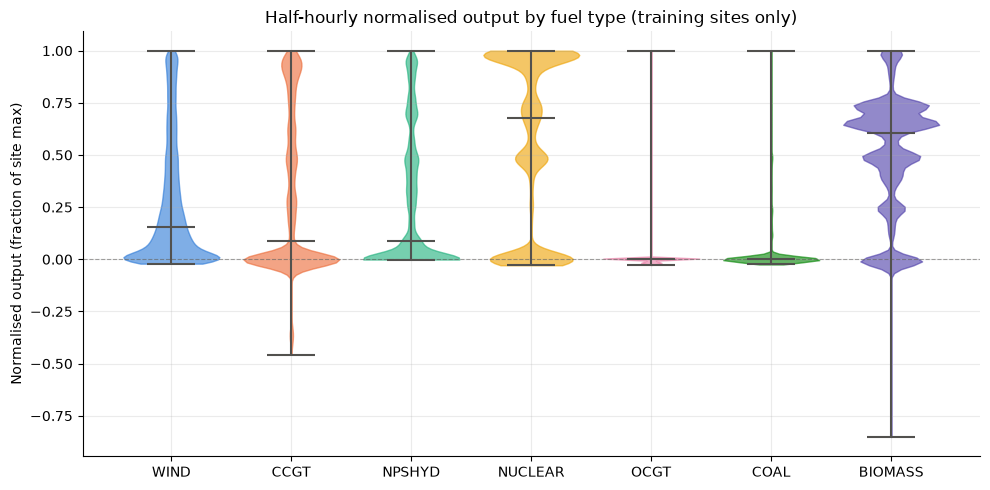

In [5]:
df["normalised"] = df["quantity"] / df["site_max_abs"]

RNG_SEED = 42
SAMPLE_PER_FUEL = 200_000


def sampled_distributions(frame, value_col, fuel_types=FUEL_TYPES, n=SAMPLE_PER_FUEL, seed=RNG_SEED):
    rng = np.random.default_rng(seed)
    samples = []
    for ft in fuel_types:
        vals = frame.loc[frame["fuel_type"] == ft, value_col].dropna().to_numpy()
        if len(vals) > n:
            vals = rng.choice(vals, size=n, replace=False)
        samples.append(vals)
    return samples


def plot_violin(frame, value_col, title, ax=None, ylabel="Normalised output (fraction of site max)"):
    if ax is None:
        _, ax = plt.subplots(figsize=(10, 5))
    samples = sampled_distributions(frame, value_col)
    parts = ax.violinplot(samples, showmedians=True, widths=0.8)
    for i, body in enumerate(parts["bodies"]):
        colour = FUEL_COLOURS[FUEL_TYPES[i]]
        body.set_facecolor(colour)
        body.set_edgecolor(colour)
        body.set_alpha(0.6)
    for key in ("cbars", "cmins", "cmaxes", "cmedians"):
        parts[key].set_color("#52514e")
    ax.set_xticks(range(1, len(FUEL_TYPES) + 1))
    ax.set_xticklabels(FUEL_TYPES)
    ax.set_ylabel(ylabel)
    ax.set_title(title)
    ax.axhline(0, color="#52514e", linewidth=0.8, linestyle="--", alpha=0.5)
    return ax


plot_violin(df, "normalised", "Half-hourly normalised output by fuel type (training sites only)")
plt.tight_layout()
plt.show()

## Step 3 — Daily resolution: does aggregation wash out the zero-inflation? Same half-hourly-derived site scale used for both resolutions.

In [6]:
daily = (
    df.groupby(["site_fuel_id", "fuel_type", "settlementDate"], as_index=False)["quantity"]
    .mean()
    .rename(columns={"settlementDate": "date"})
)
daily["site_max_abs"] = daily["site_fuel_id"].map(site_max)  # same half-hourly-derived scale as Step 1
daily["abs_quantity"] = daily["quantity"].abs()
daily["normalised"] = daily["quantity"] / daily["site_max_abs"]

daily_zero_inflation = daily.groupby("fuel_type").apply(near_zero_proportion, include_groups=False).reindex(FUEL_TYPES)

print(f"Half-hourly rows: {len(df):,}  ->  Daily rows: {len(daily):,}")
print()
print("Daily near-zero proportion, pooled across all training-site days per fuel type:")
print(daily_zero_inflation.round(4))

Half-hourly rows: 16,664,266  ->  Daily rows: 348,169

Daily near-zero proportion, pooled across all training-site days per fuel type:
           <= 1% of site max  <= 5% of site max  <= 10% of site max
fuel_type                                                          
WIND                  0.0811             0.1999              0.3169
CCGT                  0.3408             0.3775              0.4124
NPSHYD                0.1586             0.2165              0.3157
NUCLEAR               0.2835             0.2939              0.2943
OCGT                  0.8787             0.9914              0.9966
COAL                  0.7841             0.8075              0.8376
BIOMASS               0.1002             0.1344              0.1387


In [7]:
# Side-by-side comparison at the 5% threshold (the middle of the swept range) for readability;
# the full sweep for both resolutions is in the two tables above
comparison = pd.DataFrame({
    "half-hourly": hh_zero_inflation["<= 5% of site max"],
    "daily": daily_zero_inflation["<= 5% of site max"],
})
comparison["absolute change (pp)"] = (comparison["daily"] - comparison["half-hourly"]) * 100
comparison["relative change"] = (comparison["daily"] / comparison["half-hourly"] - 1)

print("Near-zero proportion (<=5% of site max threshold): half-hourly vs daily")
comparison.style.format({
    "half-hourly": "{:.1%}", "daily": "{:.1%}",
    "absolute change (pp)": "{:+.1f}", "relative change": "{:+.1%}",
})

Near-zero proportion (<=5% of site max threshold): half-hourly vs daily


,half-hourly,daily,absolute change (pp),relative change
fuel_type,,,,
WIND,32.1%,20.0%,-12.1,-37.7%
CCGT,47.1%,37.7%,-9.4,-19.9%
NPSHYD,45.5%,21.7%,-23.9,-52.4%
NUCLEAR,29.5%,29.4%,-0.1,-0.3%
OCGT,99.7%,99.1%,-0.6,-0.6%
COAL,84.6%,80.8%,-3.9,-4.6%
BIOMASS,14.2%,13.4%,-0.8,-5.5%


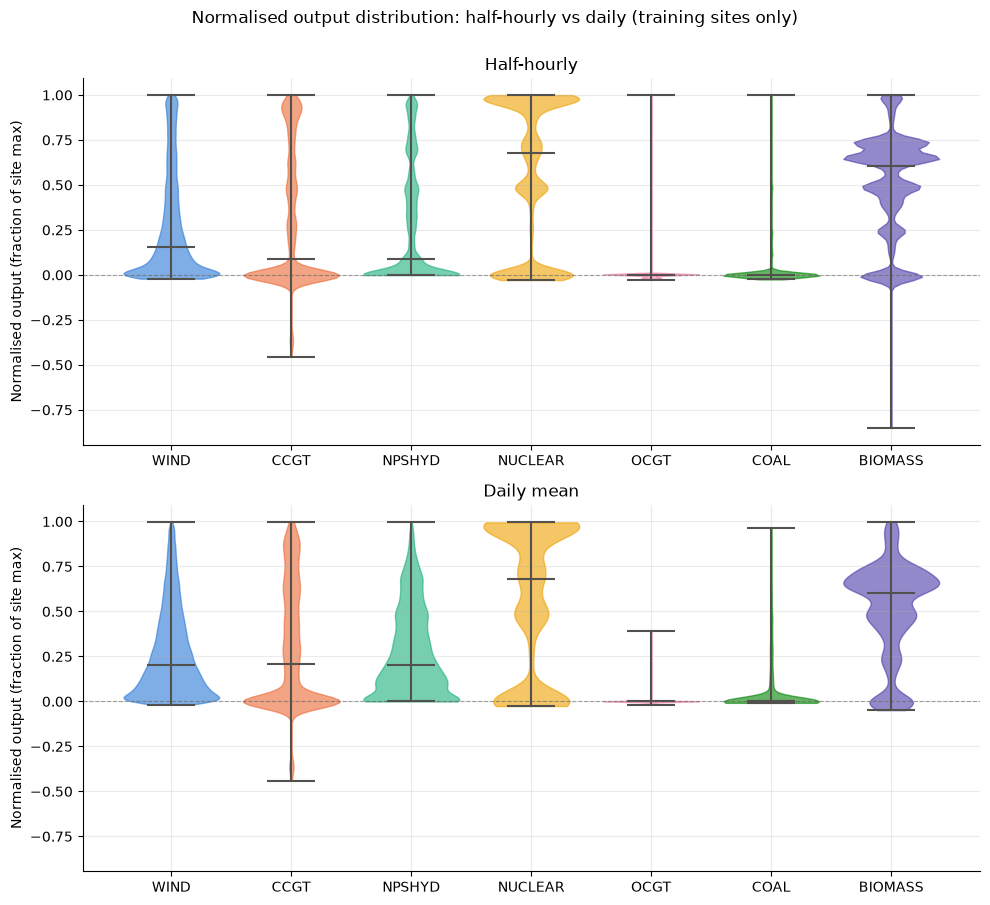

In [8]:
fig, axes = plt.subplots(2, 1, figsize=(10, 9), sharey=True)
plot_violin(df, "normalised", "Half-hourly", ax=axes[0])
plot_violin(daily, "normalised", "Daily mean", ax=axes[1])
fig.suptitle("Normalised output distribution: half-hourly vs daily (training sites only)", y=1.0)
plt.tight_layout()
plt.show()

## Step 4 — Week-level detail: half-hourly vs daily, one representative site each for WIND/NUCLEAR/OCGT, picked by highest observed max output (an earlier "most complete record" selection picked two dead BMUs instead) and each site's own most active week.

In [9]:
REPRESENTATIVE_FUEL_TYPES = ["WIND", "NUCLEAR", "OCGT"]

representative_sites = {}
representative_weeks = {}
for ft in REPRESENTATIVE_FUEL_TYPES:
    ft_df = df.loc[df["fuel_type"] == ft]
    site = ft_df.groupby("site_fuel_id")["site_max_abs"].first().idxmax()  # largest real capacity, not just longest record
    representative_sites[ft] = site

    site_df = ft_df.loc[ft_df["site_fuel_id"] == site].copy()
    site_df["week_start"] = site_df["timestamp"].dt.to_period("W-SUN").dt.start_time
    weekly_activity = site_df.groupby("week_start")["abs_quantity"].sum()
    full_weeks = site_df.groupby("week_start").size()
    weekly_activity = weekly_activity[full_weeks >= 336]  # only consider genuinely complete weeks
    representative_weeks[ft] = weekly_activity.idxmax()

print("Representative training site and its most active complete week, per fuel type:")
for ft in REPRESENTATIVE_FUEL_TYPES:
    site = representative_sites[ft]
    week = representative_weeks[ft]
    obs_max = df.loc[df["site_fuel_id"] == site, "site_max_abs"].iloc[0]
    print(f"  {ft:8s} -> {site:16s} (observed max {obs_max:7.1f} MW) | week of {week.date()}")

Representative training site and its most active complete week, per fuel type:
  WIND     -> 10242_WIND       (observed max   757.8 MW) | week of 2020-02-17
  NUCLEAR  -> 10131_NUCLEAR    (observed max  1189.2 MW) | week of 2024-10-28
  OCGT     -> 10097_OCGT       (observed max    70.3 MW) | week of 2022-08-22


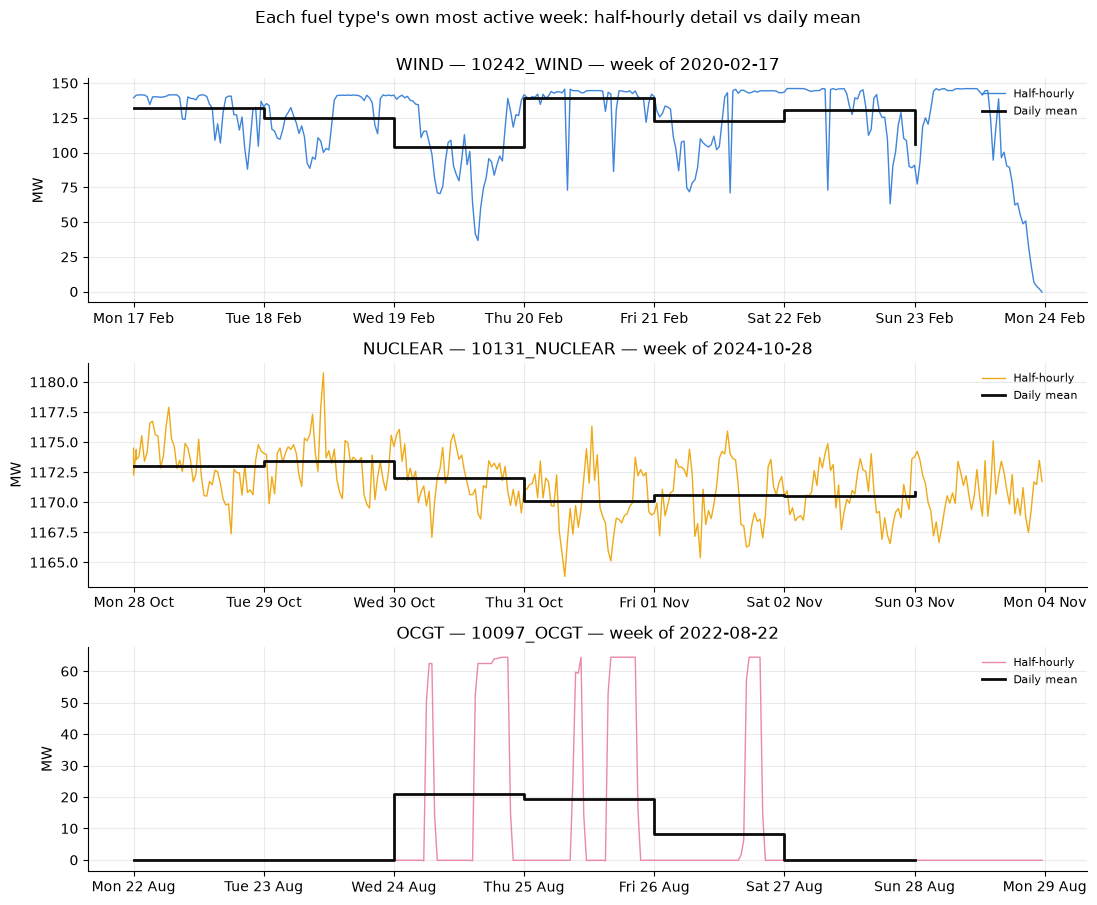

In [10]:
fig, axes = plt.subplots(len(REPRESENTATIVE_FUEL_TYPES), 1, figsize=(11, 9), sharex=False)

for ax, ft in zip(axes, REPRESENTATIVE_FUEL_TYPES):
    site = representative_sites[ft]
    week_start = representative_weeks[ft]
    week_end = week_start + pd.Timedelta(days=7)
    colour = FUEL_COLOURS[ft]

    hh_week = df.loc[(df["site_fuel_id"] == site) & df["timestamp"].between(week_start, week_end, inclusive="left")].sort_values("timestamp")
    daily_week = daily.loc[(daily["site_fuel_id"] == site) & daily["date"].between(week_start, week_end, inclusive="left")].sort_values("date")

    ax.plot(hh_week["timestamp"], hh_week["quantity"], color=colour, linewidth=1, alpha=0.9, label="Half-hourly")
    ax.step(daily_week["date"], daily_week["quantity"], where="post", color="#0b0b0b", linewidth=2, label="Daily mean")

    ax.set_title(f"{ft} \u2014 {site} \u2014 week of {week_start.date()}")
    ax.set_ylabel("MW")
    ax.legend(loc="upper right", frameon=False, fontsize=8)
    ax.xaxis.set_major_formatter(mdates.DateFormatter("%a %d %b"))

fig.suptitle("Each fuel type's own most active week: half-hourly detail vs daily mean", y=1.0)
plt.tight_layout()
plt.show()

## Step 5 — Seasonal check: monthly mean normalised output from half-hourly data vs from Step 3's daily means — divergence would mean daily resolution loses seasonal texture.

Largest monthly difference between the two computation paths (any fuel type, any month): 0.00877


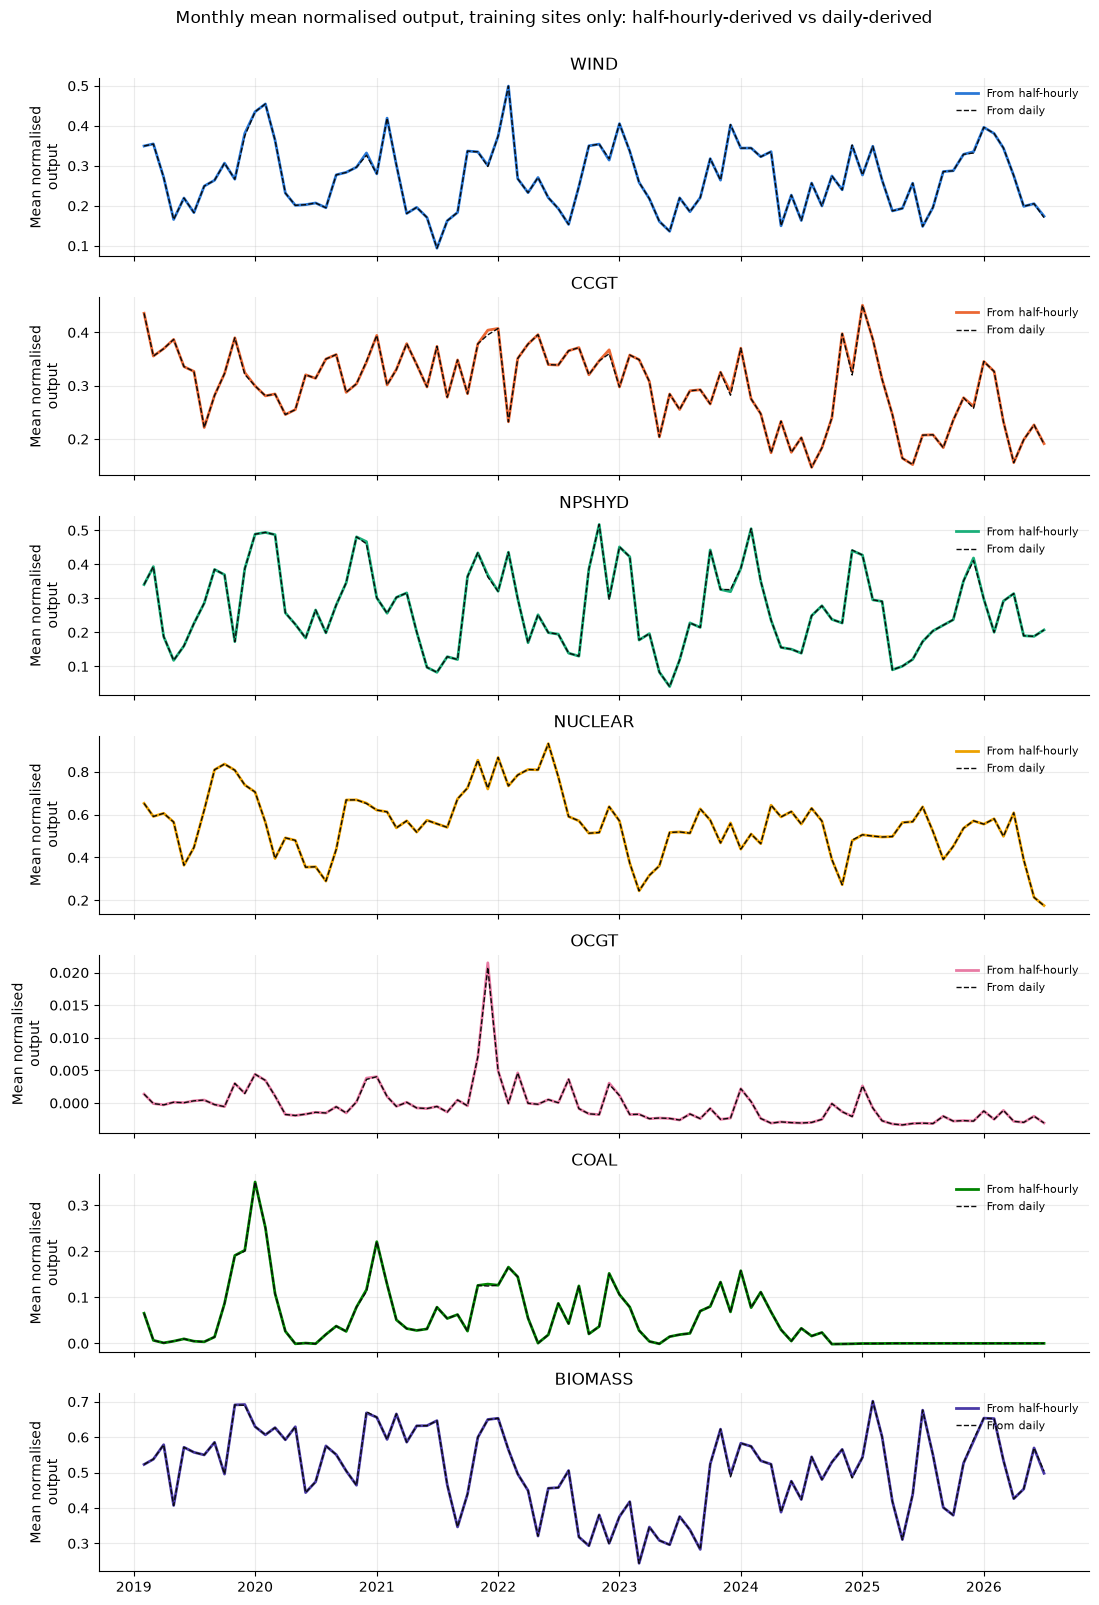

In [11]:
df["month"] = df["timestamp"].dt.to_period("M")
daily["month"] = daily["date"].dt.to_period("M")

monthly_from_hh = df.groupby(["fuel_type", "month"])["normalised"].mean().rename("from_half_hourly")
monthly_from_daily = daily.groupby(["fuel_type", "month"])["normalised"].mean().rename("from_daily")
monthly = pd.concat([monthly_from_hh, monthly_from_daily], axis=1).reset_index()
monthly["month_ts"] = monthly["month"].dt.to_timestamp()

max_abs_diff = (monthly["from_half_hourly"] - monthly["from_daily"]).abs().max()
print(f"Largest monthly difference between the two computation paths (any fuel type, any month): {max_abs_diff:.5f}")

fig, axes = plt.subplots(len(FUEL_TYPES), 1, figsize=(11, 16), sharex=True)
for ax, ft in zip(axes, FUEL_TYPES):
    sub = monthly.loc[monthly["fuel_type"] == ft].sort_values("month_ts")
    colour = FUEL_COLOURS[ft]
    ax.plot(sub["month_ts"], sub["from_half_hourly"], color=colour, linewidth=2, label="From half-hourly")
    ax.plot(sub["month_ts"], sub["from_daily"], color="#0b0b0b", linewidth=1, linestyle="--", label="From daily")
    ax.set_title(ft)
    ax.set_ylabel("Mean normalised\noutput")
    ax.legend(loc="upper right", frameon=False, fontsize=8)

axes[-1].xaxis.set_major_formatter(mdates.DateFormatter("%Y"))
fig.suptitle("Monthly mean normalised output, training sites only: half-hourly-derived vs daily-derived", y=1.0)
plt.tight_layout()
plt.show()

## Decision log

**Granularity confirmed: half-hourly.** Daily aggregation actively misrepresents intermittent fuel types (OCGT worst case: sharp on/off spikes read as a smooth partial ramp once daily-averaged) while baseload types (NUCLEAR) lose almost nothing. This notebook's Step 1 also surfaced the second instance of the "registered but not delivering" dead-site pattern (`10128_NUCLEAR`, `10139_NUCLEAR`), which prompted the fleet-wide, all-splits sweep now living in `notebooks/dead_site_sweep.ipynb`.